# Quadratic Discriminant Analysis (QDA)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "pl_eqt", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(df)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 17)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 17) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {"reg_param": [0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]}

grid_qda = run_grid_search(
    QuadraticDiscriminantAnalysis(store_covariance=True),
    param_grid,
    X_train_bal,
    y_train_bal,
)
qda = grid_qda.best_estimator_

y_pred_qda = qda.predict(X_test_scaled)
y_prob_qda = qda.predict_proba(X_test_scaled)

print(f"Best params: {grid_qda.best_params_}")
print(f"Best CV F1 Macro: {grid_qda.best_score_:.4f}")
print("QDA training complete.")
print(f"Test predictions shape: {y_pred_qda.shape}")

Best params: {'reg_param': 0.001}
Best CV F1 Macro: 0.9757
QDA training complete.
Test predictions shape: (1114,)


### Seed-Sweep Evaluation

Grid search above tuned `reg_param` on `random_state=42` only. The single test F1 macro from one split is a noisy estimate when minority test classes have only 6 mesoplanet and 8 psychroplanet samples. Re-evaluate with the tuned regularisation across 50 random splits, capturing per-seed confusion matrices and predicted probabilities for downstream aggregated diagnostics.

The class-mean heatmap and per-class variance bars above stay at seed=42 — they're model-internals visualisations ("here's what QDA learned about each class") whose qualitative story doesn't change meaningfully across seeds, and aggregating them would obscure that visualisation. The posterior violin plot below replaces the original single-seed version since 50 splits × tiny minority classes give genuine statistical mass to the probability distributions.

In [4]:
sweep_qda = run_seed_sweep(
    lambda cw: QuadraticDiscriminantAnalysis(**grid_qda.best_params_),
    df,
    n_seeds=50,
    model_name="QDA",
    save_csv="sweep_qda.csv",
    save_pickle="sweep_qda.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/si

QDA — 50-seed sweep
  F1 macro:    0.5833 ± 0.0471  (SEM 0.0067, min 0.4805, max 0.6719)
  F1 weighted: 0.9708 ± 0.0042
  Captured per-seed: predict_proba, decision_function
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_qda.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_qda.pkl


## Modeling
### DIAGNOSTIC PLOT 1: Learned Class Means per Feature

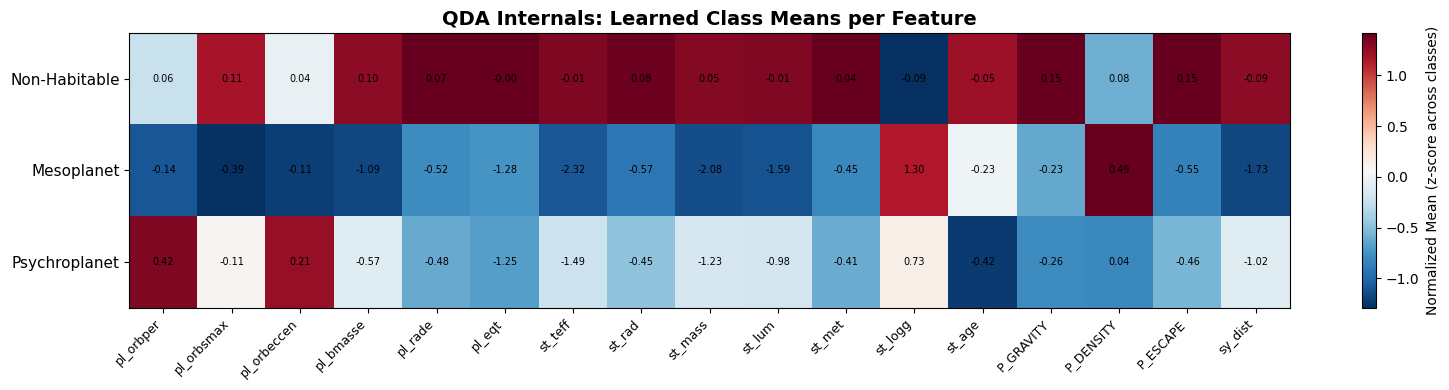

↑ Each row is the mean feature vector QDA learned for that class.
  Blue = below average, Red = above average across classes.
  Large colour contrast = strong class-level difference on that feature.


In [5]:
means = qda.means_  # shape (3, n_features)
means_norm = (means - means.mean(axis=0)) / (means.std(axis=0) + 1e-12)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(means_norm, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels(class_names, fontsize=11)
plt.colorbar(im, ax=ax, label="Normalized Mean (z-score across classes)")

for i in range(3):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{means[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black")

ax.set_title("QDA Internals: Learned Class Means per Feature",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_plot("qda_class_means")
plt.show()

print("↑ Each row is the mean feature vector QDA learned for that class.")
print("  Blue = below average, Red = above average across classes.")
print("  Large colour contrast = strong class-level difference on that feature.")

### DIAGNOSTIC PLOT 2: Per-Class Feature Variances

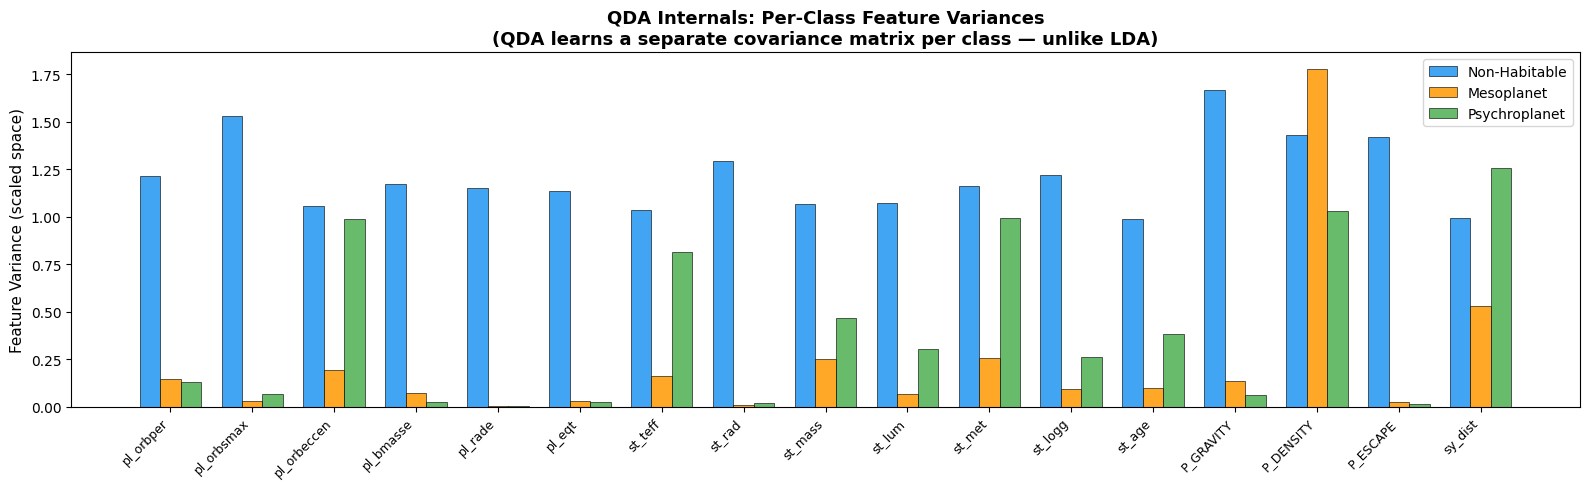

↑ QDA allows each class to have its own spread per feature.
  Large variance differences between classes = QDA uses a non-linear boundary on that feature.
  Features with near-equal bars = class covariances agree there — LDA would handle it the same.


In [6]:
variances = np.array([np.diag(cov) for cov in qda.covariance_])  # shape (3, n_features)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(FEATURES))
width = 0.25

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    ax.bar(x + i * width, variances[i], width=width, color=color,
           label=label, edgecolor="black", linewidth=0.5, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Feature Variance (scaled space)", fontsize=11)
ax.set_title("QDA Internals: Per-Class Feature Variances\n"
             "(QDA learns a separate covariance matrix per class — unlike LDA)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("qda_class_variances")
plt.show()

print("↑ QDA allows each class to have its own spread per feature.")
print("  Large variance differences between classes = QDA uses a non-linear boundary on that feature.")
print("  Features with near-equal bars = class covariances agree there — LDA would handle it the same.")

### DIAGNOSTIC PLOT 3: Posterior Probability Distributions by True Class

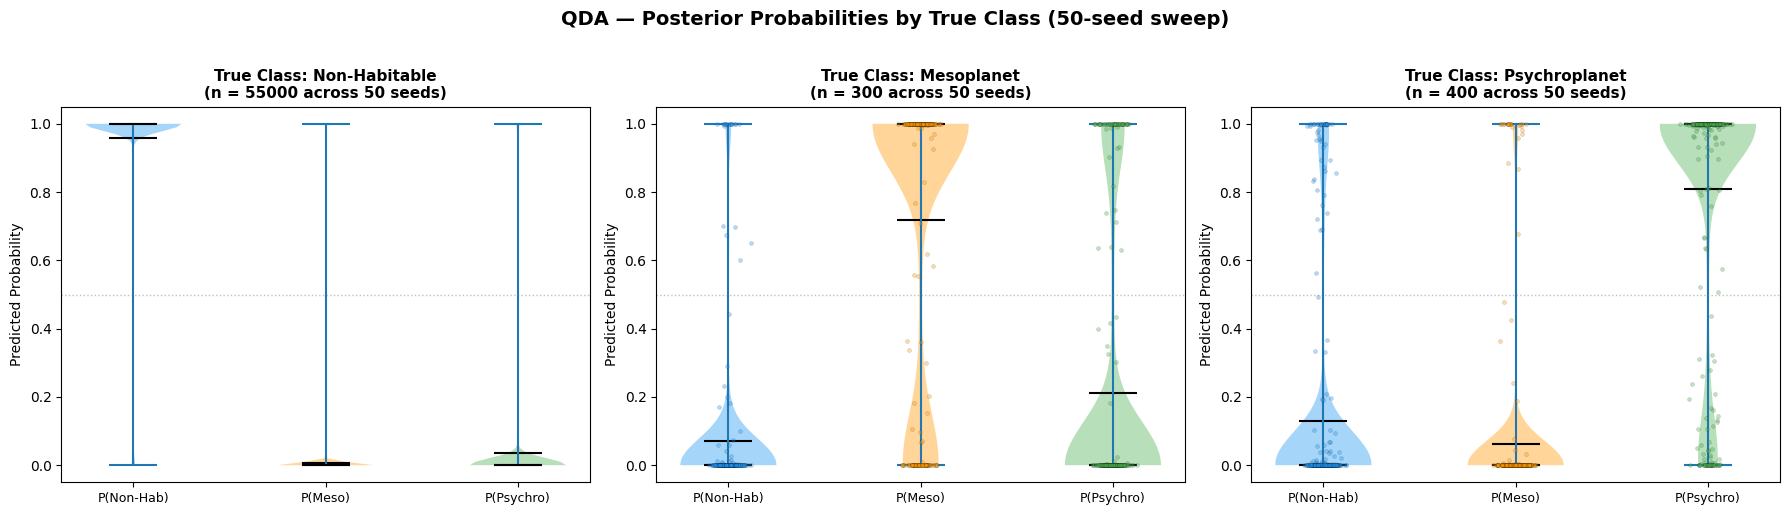

↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 probability
  points per minority panel, the violins now carry real statistical mass — unlike the single-
  split version where 6–8 samples produced uninformative shapes.
  A well-calibrated QDA concentrates P(true class) near 1.0 across most splits.
  Wide spreads on minority panels reflect QDA's reliance on per-class covariance estimates
  fit on small minority training samples — variance is structurally hard for QDA here.


In [7]:
plot_sweep_posterior_violins(sweep_qda)

print("↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 probability")
print("  points per minority panel, the violins now carry real statistical mass — unlike the single-")
print("  split version where 6–8 samples produced uninformative shapes.")
print("  A well-calibrated QDA concentrates P(true class) near 1.0 across most splits.")
print("  Wide spreads on minority panels reflect QDA's reliance on per-class covariance estimates")
print("  fit on small minority training samples — variance is structurally hard for QDA here.")

## Metrics
### Classification Report

QDA — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9785     0.0037     0.9691     0.9848
Mesoplanet           0.5326     0.1237     0.2667     0.7692
Psychroplanet        0.2389     0.0570     0.0952     0.3429
----------------------------------------------------------------
Macro avg            0.5833     0.0471     0.4805     0.6719
Weighted avg         0.9708     0.0042     0.9597     0.9781

5-Fold CV F1 Macro: 0.9713 ± 0.0046

QDA — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9986 ± 0.0012    0.9592 ± 0.0069
Mesoplanet       0.4334 ± 0.1166    0.7200 ± 0.1796
Psychroplanet    0.1408 ± 0.0355    0.8100 ± 0.1736
----------------------------------------------------------------
Macro avg        0.5243 ± 0.0415    0.8297 ± 0.0726
Wei

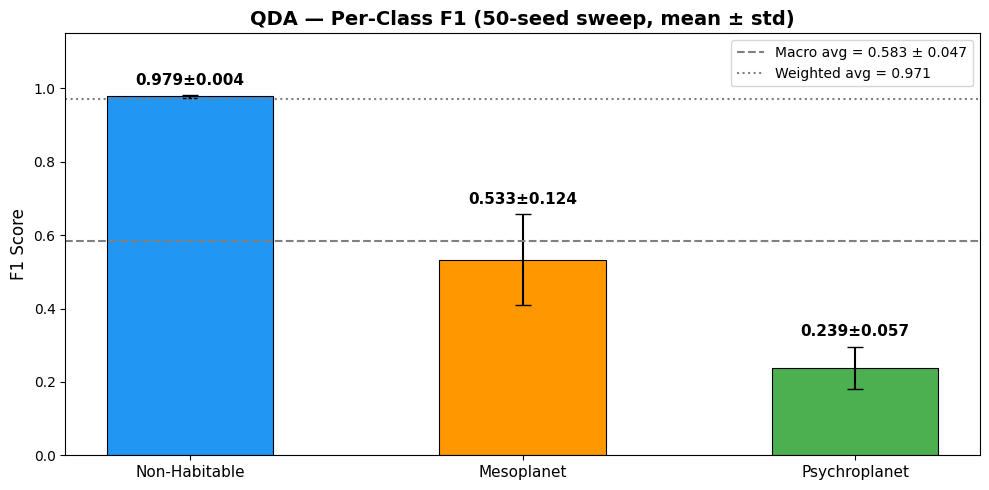

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_qda)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_qda = run_stratified_cv(qda, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_qda)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_qda)

### Confusion Matrix (Counts + Normalized)

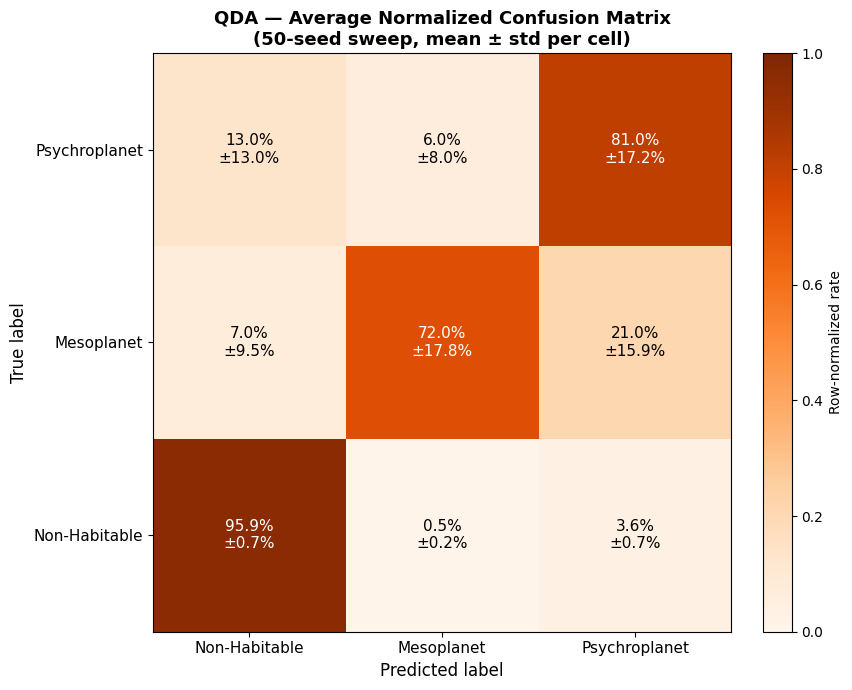

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 5.56 ± 2.42 per split  (0.5% ± 0.2% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 39.28 ± 7.48 per split  (3.6% ± 0.7% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.42 ± 0.57 per split  (7.0% ± 9.5% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 1.26 ± 0.96 per split  (21.0% ± 15.9% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 1.04 ± 1.04 per split  (13.0% ± 13.0% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.48 ± 0.64 per split  (6.0% ± 8.0% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_qda)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_qda)

## Interpretation:
